## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. Regression is a tool that is used on infinite sets, normally to predict some type of numerical value; Classification on the other hand, is used on finite sets normally to predict some type of categorical or set labels, instead of numbers.
2. A confusion matrix is a grid of predict vs actual values, showing how many landing in a specific column or row box. Columns are normally predicted values, which could span from simple "Yes or No's" to more complicated values. Rows list what the actual value shown was, in the same categories as the columns. Therefore, the grid is a perfect square, and numbers of how many data points fell into each square are shown. Sometimes, the squares are also colored based on density of values.
3. The sum of squared errors showcases the difference between the actual values and the predicted values given by the regression plot or model. It takes the sum of the squared differences between each data point and uses that to calculate a value. If an SSE is higher, it means the data is more random and less fit by a perfect regressional model, whereas a lower SSE is the opposite.
4. Data is split into 2 different dev fields: Testing and Training. In both of these cases, the model performs bad on the testing data, due to how the training data is done. Underfitting is when some type of model wasn't trained enough or is too simple, causing it to perform bad on both different fields; on the other hand, Overfitting performed really well on the training data, but due to over training, it starts performing bad on the testing data.
5. First, training sets are used to actually calibrate the model. Without calibration, the model won't know what the data looks like, causing it to give inaccurate values. With this training data, it calibrates the model to start accurately representing data, while also discounting outliers. When it gets to testing, as long as it's not overfit or underfit, it will be able to read these new but similar data sets and accurately process it. Calculating the SSE on this test set is important as this is the final data sets similar to real world data, and it should be able to perform well and receive a low SSE, compared to training where it's still learning.
6. A prediction is a quick data point showcasing the most likely solution or answer for a given data set. The strengths are that it gives a fast answer for systems based on the most logical conclusion for the data, but, this can cause a misrepresentation of the data and not show all the possible outcomes. This is where probability distributions come in, it shows all the different cases and the probability that they occur. For models or data that wants to see all the outcomes or show uncertainty, this is better, but for quicker single answers, this can cause a lot more issues overpredictions.

**Q2.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for evaluation.
4. Use the $k$NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

---------------- Part 1 ---------------

Dimensions (Rows, Columns): (2499, 3)
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
5   5700  2018    45561
6   7300  2010   149050
7  13350  2017    23525
8  14600  2018     9371
9   5250  2017    63418
price      0
year       0
mileage    0
dtype: int64
---------------- Part 2 ---------------

       year   mileage
0  0.744681  0.269287
1  0.808511  0.187194
2  0.957447  0.038892
3  0.872340  0.063016
4  0.957447  0.006537
              year      mileage
count  2499.000000  2499.000000
mean      0.930091     0.051377
std       0.073248     0.058654
min       0.000000     0.000000
25%       0.914894     0.021088
50%       0.957447     0.034742
75%       0.978723     0.062354
max       1.000000     1.000000
---------------- Part 3 ---------------

Data Split!
---------------- Part 4 ---------------



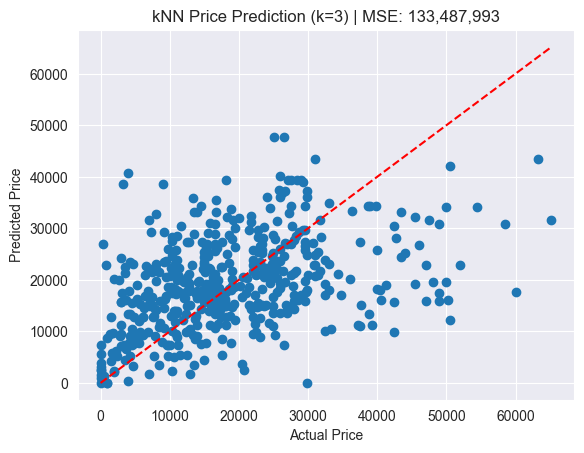

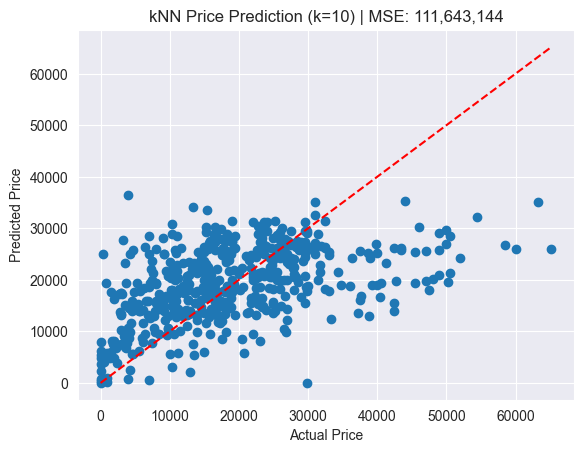

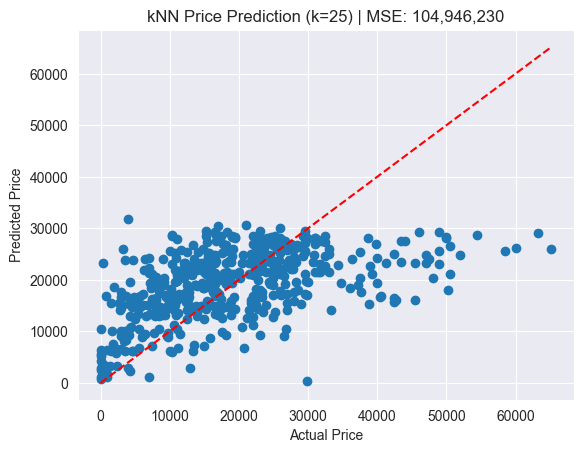

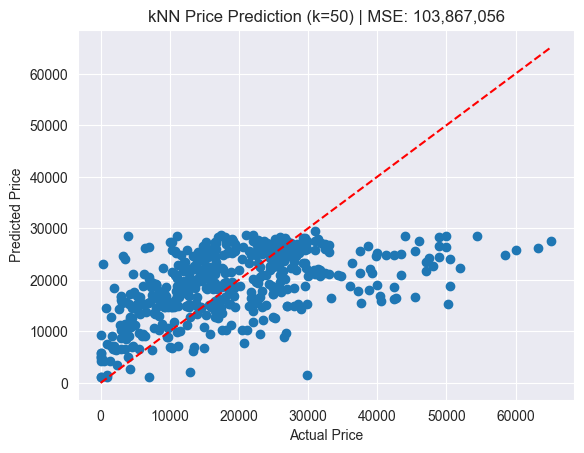

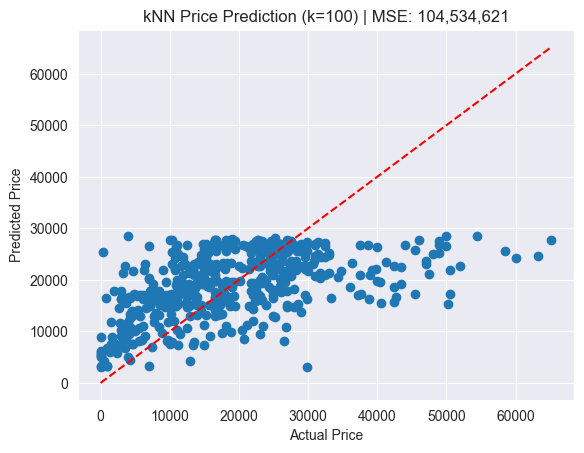

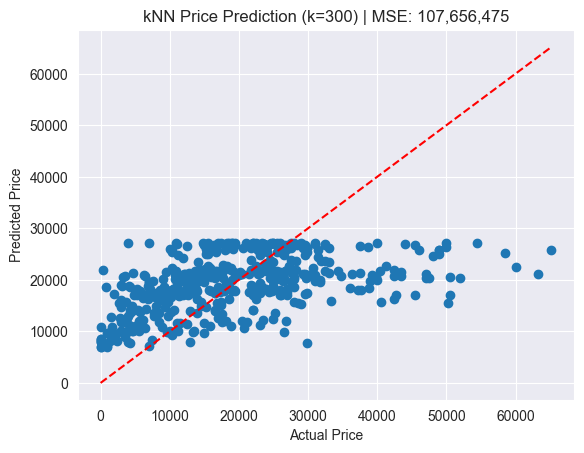

4. It seems that as the k value increases, the data points start to max at around 30k prediected price, as starting at k=50, no points are above that line. Also, the MSE value goes down rapidly for the first few graphs, but after that starts to slowly climb
---------------- Part 5 ---------------

5. Most optimal k value is: ~50. The reason for this is because it's the area of lowest MSE compared to the other graphs, an exact k value can be found by looping through all possible k values around that point and seeing which has the lowest
---------------- Part 6 ---------------

6. At the start, the data with the lowest k values likely experienced underfitting. This is shown due to the extremely high values given in the predicted range, showing that it predicted really high car values, but in reality they were grouped lower.  The later k values are likely experience overfitting, where they went through so much testing that they started to become fixated on certain outliers, and because of

In [48]:
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
from sklearn.model_selection import train_test_split

print("\n" + "---------------- Part 1 ---------------" + "\n")
df = pd.read_csv('../data/USA_cars_datasets.csv')
df = df[['price', 'year', 'mileage']]
print("Dimensions (Rows, Columns):", df.shape)
print(df.head(10))
print(df.isnull().sum())

print("\n" + "---------------- Part 2 ---------------" + "\n")
def maxmin(z):
    z = (z - z.min()) / (z.max() - z.min())
    return(z)
df["year"] = maxmin(df['year'])
df["mileage"] = maxmin(df['mileage'])
print(df[["year", "mileage"]].head())
print(df[["year", "mileage"]].describe())

print("\n" + "---------------- Part 3 ---------------" + "\n")
X = df[['year', 'mileage']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=65)
print ("Data Split!")

print("\n" + "---------------- Part 4 ---------------" + "\n")
k_values = [3, 10, 25, 50, 100, 300]

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mean = mean_squared_error(y_test, y_pred)
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"kNN Price Prediction (k={k}) | MSE: {mean:,.0f}") # Had Gemini help me setup the plot and title line, the rest I did.
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()
print("\n" + "4. It seems that as the k value increases, the data points start to max at around 30k prediected price, as starting at k=50, no points are above that line. Also, the MSE value goes down rapidly for the first few graphs, but after that starts to slowly climb")

print("\n" + "---------------- Part 5 ---------------" + "\n")
print("5. Most optimal k value is: ~50. The reason for this is because it's the area of lowest MSE compared to the other graphs, an exact k value can be found by looping through all possible k values around that point and seeing which has the lowest")

print("\n" + "---------------- Part 6 ---------------" + "\n")
print ("6. At the start, the data with the lowest k values likely experienced underfitting. This is shown due to the extremely high values given in the predicted range, showing that it predicted really high car values, but in reality they were grouped lower.  The later k values are likely experience overfitting, where they went through so much testing that they started to become fixated on certain outliers, and because of that became less reliable with the data.")


**Q3.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.


---------------- Part 1 ---------------

{1}
aardvark, antelope, bear, boar, buffalo, calf, cavy, cheetah, deer, dolphin, elephant, fruitbat, giraffe, girl, goat, gorilla, hamster, hare, leopard, lion, lynx, mink, mole, mongoose, opossum, oryx, platypus, polecat, pony, porpoise, puma, pussycat, raccoon, reindeer, seal, sealion, squirrel, vampire, vole, wallaby, wolf
{2}
chicken, crow, dove, duck, flamingo, gull, hawk, kiwi, lark, ostrich, parakeet, penguin, pheasant, rhea, skimmer, skua, sparrow, swan, vulture, wren
{3}
pitviper, seasnake, slowworm, tortoise, tuatara
{4}
bass, carp, catfish, chub, dogfish, haddock, herring, pike, piranha, seahorse, sole, stingray, tuna
{5}
frog, frog, newt, toad
{6}
flea, gnat, honeybee, housefly, ladybird, moth, termite, wasp
{7}
clam, crab, crayfish, lobster, octopus, scorpion, seawasp, slug, starfish, worm
class
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64
          hair  feathers      eggs      milk  airborne  

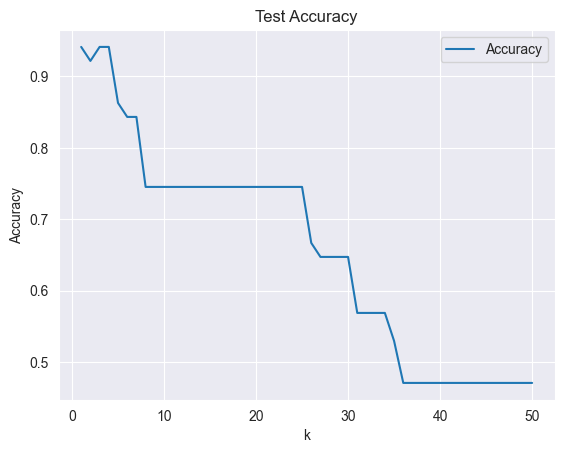

col_0   1   2  3  4  5  6  7
class                       
1      24   0  0  0  0  0  0
2       0  10  0  0  0  0  0
3       1   0  1  0  1  0  0
4       0   0  0  4  0  0  0
5       0   0  0  0  1  0  0
6       0   0  0  0  0  5  0
7       0   0  0  0  1  0  3
It seems accurate for the most part. Most data sets were in the correct place, with a few outliers predicted in the wrong place, such as class 3. As the k values started to increase, the data became more and more overfitted, such as around k=25 as shown in this specific test case. K=1 was actually the best area to compute this data on. Mistakes were likely because of this small data set and doing a 50/50 split

---------------- Part 5 ---------------

[ 1  7 12 13]


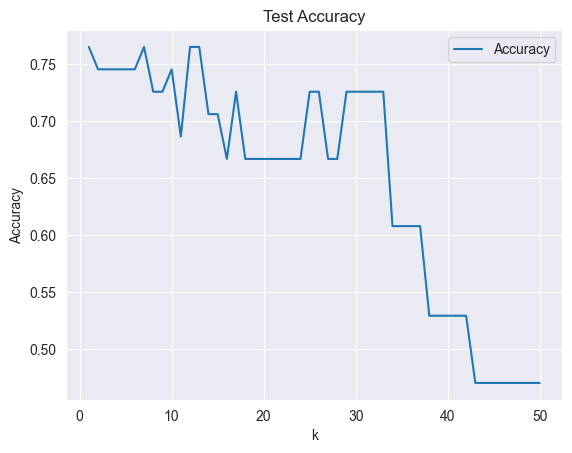

col_0   1  2  4  7
class             
1      24  0  0  0
2       0  9  0  1
3       0  0  0  3
4       0  0  4  0
5       0  0  1  0
6       0  4  0  1
7       0  0  2  2


[[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 

In [51]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import train_test_split

print("\n" + "---------------- Part 1 ---------------" + "\n")
df = pd.read_csv('../data/animals.csv')
for class_label, group in df.groupby('class'):
    print({class_label})
    animals_in_group = ", ".join(group['animal'].values)
    print(animals_in_group)
print(df["class"].value_counts())
traits = df.drop(['animal', 'class'], axis=1)
print(traits.describe().loc[['mean', 'std']]) # Asked gemini what the best way was to describe the mean and std without looping through using the describe function, which is what I assumed would be used just didn't know to add .loc to it.
print("Different variables that are more rare, such eggs or milk, could better predict each class because they are likely unique to specific factors, whereas something like breathing is going to be more common across many different classes")

print("\n" + "---------------- Part 2+3+4 ---------------" + "\n")
def maxmin(z):
    z = (z - z.min()) / (z.max() - z.min())
    return(z)
df["legs"] = maxmin(df['legs'])
# Best k (Example given by slides)
X = traits
y = df['class']

def kClassifier(X,y,new = False):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.5, random_state=13)
    k_bar = 50
    Acc = []
    N_train = len(y_train)
    N_test = len(y_test)

    for k in range(k_bar):
        model = KNeighborsClassifier(n_neighbors=k+1)
        fitted_model = model.fit(X_train.values,y_train)
        y_hat = fitted_model.predict(X_test.values)
        Acc.append( np.sum( y_hat == y_test )/N_test )

    Acc_max = np.max(Acc)
    max_index = np.where(Acc==Acc_max)
    k_star = max_index[0]+1
    print(k_star)
    # Classifier/Graphical (Also given by slides but edited as needed)
    model = KNeighborsClassifier(n_neighbors=k_star[0])
    fitted_model = model.fit(X_train.values,y_train)
    y_hat = fitted_model.predict(X_test.values)
    plt.plot(np.arange(1,k_bar+1),Acc,label='Accuracy')
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.legend(loc='upper right')
    plt.title('Test Accuracy')
    plt.show()
    print(pd.crosstab(y_test,y_hat))
    if new == True:
        probs = fitted_model.predict_proba(X_test.values)
        print ("\n")
        print(probs)

kClassifier(X,y)
print("It seems accurate for the most part. Most data sets were in the correct place, with a few outliers predicted in the wrong place, such as class 3. As the k values started to increase, the data became more and more overfitted, such as around k=25 as shown in this specific test case. K=1 was actually the best area to compute this data on. Mistakes were likely because of this small data set and doing a 50/50 split")

print("\n" + "---------------- Part 5 ---------------" + "\n")
X = df[['milk',"aquatic","airborne"]]
kClassifier(X,y,True)
print("No, they are very much not represented, as shown by the fact that on the confusion table, the columns only include 4 of the different classes, meaning the actual data for other classes was never given. This is shown by the predictional probability, no values were every in those columns on any of the data, meaning they were unrepresented and this model would be very inaccurate. ")


**Q4.** Write your own function to make a kernel density plot.

- The user should pass in a Pandas series or Numpy array.
- The default kernel should be Gaussian, but include the uniform/bump and Epanechnikov as alternatives.
- The default bandwidth should be the Silverman plug-in, but allow the user to specify an alternative.
- You can use Matplotlib or Seaborn's `.lineplot`, but not an existing function that creates kernel density plots.

You will have to make a lot of choices and experiment with getting errors. Embrace the challenge and track your choices in the comments in your code.

Use a data set from class to show that your function works, and compare it with the Seaborn `kdeplot`.

We covered the Gaussian,
$$
k(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^2/2}
$$
and uniform 
$$
k(z) = \begin{cases} 
\frac{1}{2}, & |z| \le 1 \\
0, & |z|>1
\end{cases}
$$
kernels in class, but the Epanechnikov kernel is 
$$
k(z) = \begin{cases} 
\frac{3}{4} (1-z^2), & |z| \le 1 \\
0, & |z|>1.
\end{cases}
$$

In order to make your code run reasonably quickly, consider using the `pdist` or `cdist` functions from SciPy to make distance calculations for arrays of points. The other leading alternative is to thoughtfully use NumPy's broadcasting features. Writing `for` loops will be slow, but that's fine.

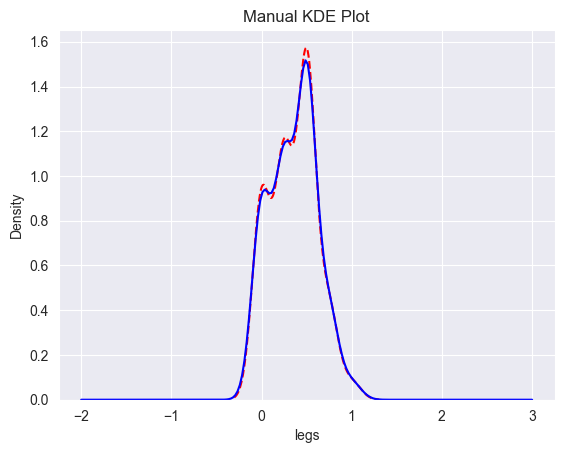

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This is the main function that does my kernel density plot, I made as much as I could and any errors I used AI to help me with.

def my_kde(data, kernel='gaussian', h=None):
    # Takes in parameters of the data, kernel, and the bandwidth. Setup the parameters well but was having issues with setting up the Silverman's basics
    # So I just made a default none and then multiplied the factor by the data and length of the data.
    if h is None:
        h = 1.06 * np.std(data) * (len(data)**(-1/5))

    # This makes a line, slighty further out from the given data, of the data.
    # Decided it would be good to go slighty out to see how it would extend further past the given parameters.
    x_grid = np.linspace(min(data) - 2, max(data) + 2, 200)

    # Just a basic array to keep the final density
    final_density = []

    # Loops through all the given points, applies the formulas.
    for x in x_grid:
        z = (x - data) / h

        # Had to get help doing this from AI because I wasn't really sure how to implement the different kernel formulas without a giant if mess. Had AI simplify them down to one line so that the code wasn't overloaded by if statements.
        if kernel == 'gaussian':
            k_z = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)
        elif kernel == 'uniform':
            k_z = np.where(np.abs(z) <= 1, 0.5, 0)
        elif kernel == 'epanechnikov':
            k_z = np.where(np.abs(z) <= 1, 0.75 * (1 - z**2), 0)

        total_height = np.sum(k_z) / (len(data) * h)
        final_density.append(total_height)

    return x_grid, final_density


# Checks the examples from earlier, the graphs are very similar, meaning that our gaussian plot is very accurate.
x_vals, y_vals = my_kde(df['legs'], kernel='gaussian')
sns.kdeplot(df['legs'], label='Seaborn KDE', color='red', linestyle='--')

plt.plot(x_vals, y_vals, label='My Gaussian KDE', color='blue')
plt.title("Manual KDE Plot")
plt.show()